# Model Development

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns
sns.set_style('whitegrid')
import os 
import glob
import random
import difflib
import warnings
warnings.filterwarnings('ignore')

### Data Ingestion

In [2]:
dataset = glob.glob(r'F:\Data Science Projects\Bank_Marketing\artifacts' + '\\**\\' + '*.csv',recursive=True)
dataset

['F:\\Data Science Projects\\Bank_Marketing\\artifacts\\bank_test.csv',
 'F:\\Data Science Projects\\Bank_Marketing\\artifacts\\bank_train.csv']

In [3]:
df_train = pd.read_csv(dataset[1])
df_train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,54,technician,married,high.school,no,no,no,telephone,may,tue,...,12,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no
1,35,management,married,university.degree,no,yes,no,cellular,apr,thu,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.365,5099.1,no
2,46,admin.,divorced,university.degree,no,yes,yes,telephone,may,tue,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,36,management,married,university.degree,no,yes,no,cellular,nov,wed,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
4,23,student,single,high.school,no,no,no,cellular,aug,mon,...,1,999,0,nonexistent,-2.9,92.201,-31.4,0.861,5076.2,no


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30570 entries, 0 to 30569
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             30570 non-null  int64  
 1   job             30570 non-null  object 
 2   marital         30570 non-null  object 
 3   education       30570 non-null  object 
 4   default         30570 non-null  object 
 5   housing         30570 non-null  object 
 6   loan            30570 non-null  object 
 7   contact         30570 non-null  object 
 8   month           30570 non-null  object 
 9   day_of_week     30570 non-null  object 
 10  duration        30570 non-null  int64  
 11  campaign        30570 non-null  int64  
 12  pdays           30570 non-null  int64  
 13  previous        30570 non-null  int64  
 14  poutcome        30570 non-null  object 
 15  emp.var.rate    30570 non-null  float64
 16  cons.price.idx  30570 non-null  float64
 17  cons.conf.idx   30570 non-null 

In [5]:
df_test = pd.read_csv(dataset[0])
df_test.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,34,blue-collar,single,basic.9y,no,no,yes,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,no
1,28,blue-collar,married,basic.4y,no,no,no,telephone,jun,thu,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,no
2,40,technician,single,professional.course,no,yes,no,cellular,may,thu,...,8,999,0,nonexistent,-1.8,92.893,-46.2,1.266,5099.1,no
3,32,technician,married,basic.9y,no,yes,no,telephone,jul,fri,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no
4,38,blue-collar,married,professional.course,no,yes,no,telephone,may,tue,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7643 entries, 0 to 7642
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             7643 non-null   int64  
 1   job             7643 non-null   object 
 2   marital         7643 non-null   object 
 3   education       7643 non-null   object 
 4   default         7643 non-null   object 
 5   housing         7643 non-null   object 
 6   loan            7643 non-null   object 
 7   contact         7643 non-null   object 
 8   month           7643 non-null   object 
 9   day_of_week     7643 non-null   object 
 10  duration        7643 non-null   int64  
 11  campaign        7643 non-null   int64  
 12  pdays           7643 non-null   int64  
 13  previous        7643 non-null   int64  
 14  poutcome        7643 non-null   object 
 15  emp.var.rate    7643 non-null   float64
 16  cons.price.idx  7643 non-null   float64
 17  cons.conf.idx   7643 non-null   f

### Defining Feature Matrix & Target Vector

Features selected after Feature Engineering

In [7]:
selected_features = [
                     'duration',
                    #  'nr.employed',
                     'euribor3m',
                    #  'emp.var.rate',
                     'poutcome',
                     'cons.price.idx',
                     'cons.conf.idx',
                     'month'
                     ]

In [8]:
Xtrain  = df_train[selected_features]
Xtest = df_test[selected_features]
print('Feature Matrix')
print('Training Set: ',Xtrain.shape)
print('Testing Set: ',Xtest.shape)

Feature Matrix
Training Set:  (30570, 6)
Testing Set:  (7643, 6)


In [9]:
ytrain = df_train['y'].map(dict(yes=1,no=0))
ytest = df_test['y'].map(dict(yes=1,no=0))
print('Target Vector')
print('Training Set: ',ytrain.shape)
print('Testing Set: ',ytest.shape)

Target Vector
Training Set:  (30570,)
Testing Set:  (7643,)


In [10]:
feature_names = Xtrain.columns.to_list()
feature_names

['duration',
 'euribor3m',
 'poutcome',
 'cons.price.idx',
 'cons.conf.idx',
 'month']

In [11]:
class_names = ['Not Subscribed','Subscribed']
class_names

['Not Subscribed', 'Subscribed']

### Model Development

In [12]:
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OrdinalEncoder,OneHotEncoder
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import precision_score,recall_score,f1_score,roc_auc_score,precision_recall_curve,roc_curve,auc,log_loss,matthews_corrcoef,classification_report,confusion_matrix
from sklearn.calibration import calibration_curve,CalibratedClassifierCV

In [13]:
from hyperopt import hp,tpe,fmin,Trials,STATUS_OK
from tqdm.notebook import tqdm

In [89]:
import lime
from lime import lime_tabular

Preprocessor

In [14]:
num_features = ['duration','euribor3m','cons.price.idx','cons.conf.idx']
num_transformer = Pipeline([('scaler',StandardScaler())])

cat_features = ['poutcome','month']
cat_transformer = Pipeline([('encoder',OrdinalEncoder())])

preprocessor = ColumnTransformer(transformers = [('num',num_transformer,num_features),
                                                 ('cat',cat_transformer,cat_features)])

Custom Functions

In [15]:
def classification_evaluation_charts(ytrue,ypred_prob):
    
    from sklearn.metrics import precision_recall_curve,roc_curve
    
    precision,recall,threshold_prc = precision_recall_curve(ytrue,ypred_prob)
    
    fpr,tpr,threshold_roc = roc_curve(ytrue,ypred_prob)
    optimal_idx = np.argmax(tpr-fpr)
    optimal_threshold_roc = threshold_roc[optimal_idx]
    
    def lift_gain_chart(ytrue,ypred_prob):
        
        df = pd.DataFrame()
        df['true'] = ytrue 
        df['pred_prob'] = ypred_prob
        df.sort_values(by='pred_prob',ascending=False,inplace=True)
        df['decile_group'] = pd.qcut(df['pred_prob'],10,duplicates='drop')
        
        lift_gain = df.groupby('decile_group').agg(['count','sum'])['true'].sort_index(ascending=False)
        lift_gain.columns = ['People Contacted','Subscription']
        lift_gain['Cumulative Subscription'] = lift_gain['Subscription'].cumsum()
        lift_gain['Percent Events'] = lift_gain['Subscription']/lift_gain['Subscription'].sum()*100
        lift_gain['Gain'] = lift_gain['Percent Events'].cumsum()
        bins = lift_gain.shape[0]
        fc = 10/bins
        lift_gain['Lift'] = lift_gain['Gain']/np.arange(10,110,10*fc)
        
        return lift_gain,bins,fc
    
    lift_gain,bins,fc = lift_gain_chart(ytrue,ypred_prob)
    
    fig,ax = plt.subplots(2,2,figsize=(20,10))
    
    ax[0][0].plot(recall,precision,color='b')
    ax[0][0].axhline(0.5,0,1,linestyle='--',color='r')
    ax[0][0].set_title('Precision-Recall Curve',size=16,pad=10)
    ax[0][0].set_xlabel('Recall',size=14,labelpad=10)
    ax[0][0].set_ylabel('Precision',size=14,labelpad=10)
    ax[0][0].tick_params(axis='both',labelsize=12)
    
    ax[0][1].plot(fpr,tpr,color='b')
    ax[0][1].plot(np.arange(0,1.1,0.1),np.arange(0,1.1,0.1),linestyle='--',color='r')
    ax[0][1].plot(fpr[optimal_idx],tpr[optimal_idx],marker='o',markersize=10,markeredgewidth=2,fillstyle='none',color='r')
    ax[0][1].text(fpr[optimal_idx]+0.02,tpr[optimal_idx]-0.04,f'Optimal Threshold = {optimal_threshold_roc:0.4f}',fontsize=12)
    ax[0][1].set_title('ROC Curve',size=16,pad=10)
    ax[0][1].set_xlabel('FPR',size=14,labelpad=10)
    ax[0][1].set_ylabel('TPR (Recall)',size=14,labelpad=10)
    ax[0][1].tick_params(axis='both',labelsize=12)
        
    ax[1][0].plot(np.arange(10,110,10*fc),np.arange(10,110,10*fc),marker='o',color='r')
    ax[1][0].plot(np.arange(10,110,10*fc),lift_gain['Gain'],marker='o',color='b')
    ax[1][0].set_title('Gain Chart',size=16,pad=10)
    ax[1][0].set_xlabel('Fraction of Total Predictions',size=14,labelpad=10)
    ax[1][0].set_ylabel('Gain',size=14,labelpad=10)
    ax[1][0].tick_params(axis='both',labelsize=12)
    
    ax[1][1].plot(np.arange(10,110,10*fc),np.repeat(1,bins),marker='o',color='r')
    ax[1][1].plot(np.arange(10,110,10*fc),lift_gain['Lift'],marker='o',color='b')
    ax[1][1].set_title('Lift Chart',size=16,pad=10)
    ax[1][1].set_xlabel('Fraction of Total Predictions',size=14,labelpad=10)
    ax[1][1].set_ylabel('Lift',size=14,labelpad=10)
    ax[1][1].tick_params(axis='both',labelsize=12)
    
    plt.tight_layout()

Sample Weights & Class Weights

In [16]:
wt1 = df_train.shape[0]/(2*df_train['y'].value_counts()['yes'])
wt1

6.13855421686747

In [17]:
wt0 = df_train.shape[0]/(2*df_train['y'].value_counts()['no'])
wt0

0.5443376068376068

In [18]:
sample_wt = [wt1 if y == 1 else wt0 for y in df_train['y']]

In [19]:
class_wt = {0:wt0,1:wt1}

#### Logistic Regression

In [130]:
from sklearn.linear_model import LogisticRegression

In [131]:
lr_pipe = make_pipeline(preprocessor,LogisticRegression(class_weight=class_wt,random_state=42,n_jobs=-1))

lr_params = {'logisticregression__C':[0.001,0.01,0.1,1,10,100],
             'logisticregression__penalty':['l1','l2','elasticnet'],
             'logisticregression__l1_ratio':[0.2,0.4,0.6,0.8],
             'logisticregression__solver':['lbfgs','liblinear','newton-cg','newton-cholesky','sag','saga']}

lr_rand = RandomizedSearchCV(lr_pipe,lr_params,scoring='roc_auc',n_jobs=-1,cv=5,random_state=42)
lr_rand.fit(Xtrain,ytrain)

lr_yhat = lr_rand.predict(Xtest)
lr_yhat_prob = lr_rand.predict_proba(Xtest)[:,1]

print('Randomized Search CV Results')
print(f'Best Score: {lr_rand.best_score_:0.2f}')
print(f'Best Parameter Space: {lr_rand.best_params_}')

print('Test Set Results')
print(f'ROC AUC Score: {roc_auc_score(ytest,lr_yhat):0.2f}')

Randomized Search CV Results
Best Score: 0.92
Best Parameter Space: {'logisticregression__solver': 'sag', 'logisticregression__penalty': 'l2', 'logisticregression__l1_ratio': 0.8, 'logisticregression__C': 100}
Test Set Results
ROC AUC Score: 0.84


In [132]:
lr_space = {'C': hp.uniform('C',0.001,100),
            'penalty': hp.choice('penalty',['l1','l2']),
            'solver':hp.choice('solver',['liblinear','saga'])}

def lr_objective(space):
    
    model = Pipeline([('preprocessor',preprocessor),('logit',LogisticRegression(class_weight=class_wt,n_jobs=-1,random_state=42,**space))])
    
    model.fit(Xtrain,ytrain)
    ypred = model.predict(Xtest)
    roc_auc = roc_auc_score(ytest,ypred).round(2)
    loss = (1 - roc_auc).round(2)
    
    return {'loss':loss,'status':STATUS_OK,'model':model}

lr_trials = Trials()
lr_hyper = fmin(fn=lr_objective,space=lr_space,algo=tpe.suggest,max_evals=20,trials=lr_trials)

print('Hyperopt Search Results')
print('Best Parameter Space:', lr_hyper)
print(f'Best Score:', 1 - lr_trials.best_trial['result']['loss'])

search_lr_hyper = lr_trials.best_trial['result']['model']
lr_hyper_yhat = search_lr_hyper.predict(Xtest)
lr_hyper_yhat_prob = search_lr_hyper.predict_proba(Xtest)[:,1]
print('Test Set Results')
print(f'ROC AUC Score: {roc_auc_score(ytest,lr_hyper_yhat):0.2f}')

100%|██████████| 20/20 [00:02<00:00,  7.07trial/s, best loss: 0.16]
Hyperopt Search Results
Best Parameter Space: {'C': 44.58734352034093, 'penalty': 1, 'solver': 1}
Best Score: 0.84
Test Set Results
ROC AUC Score: 0.84


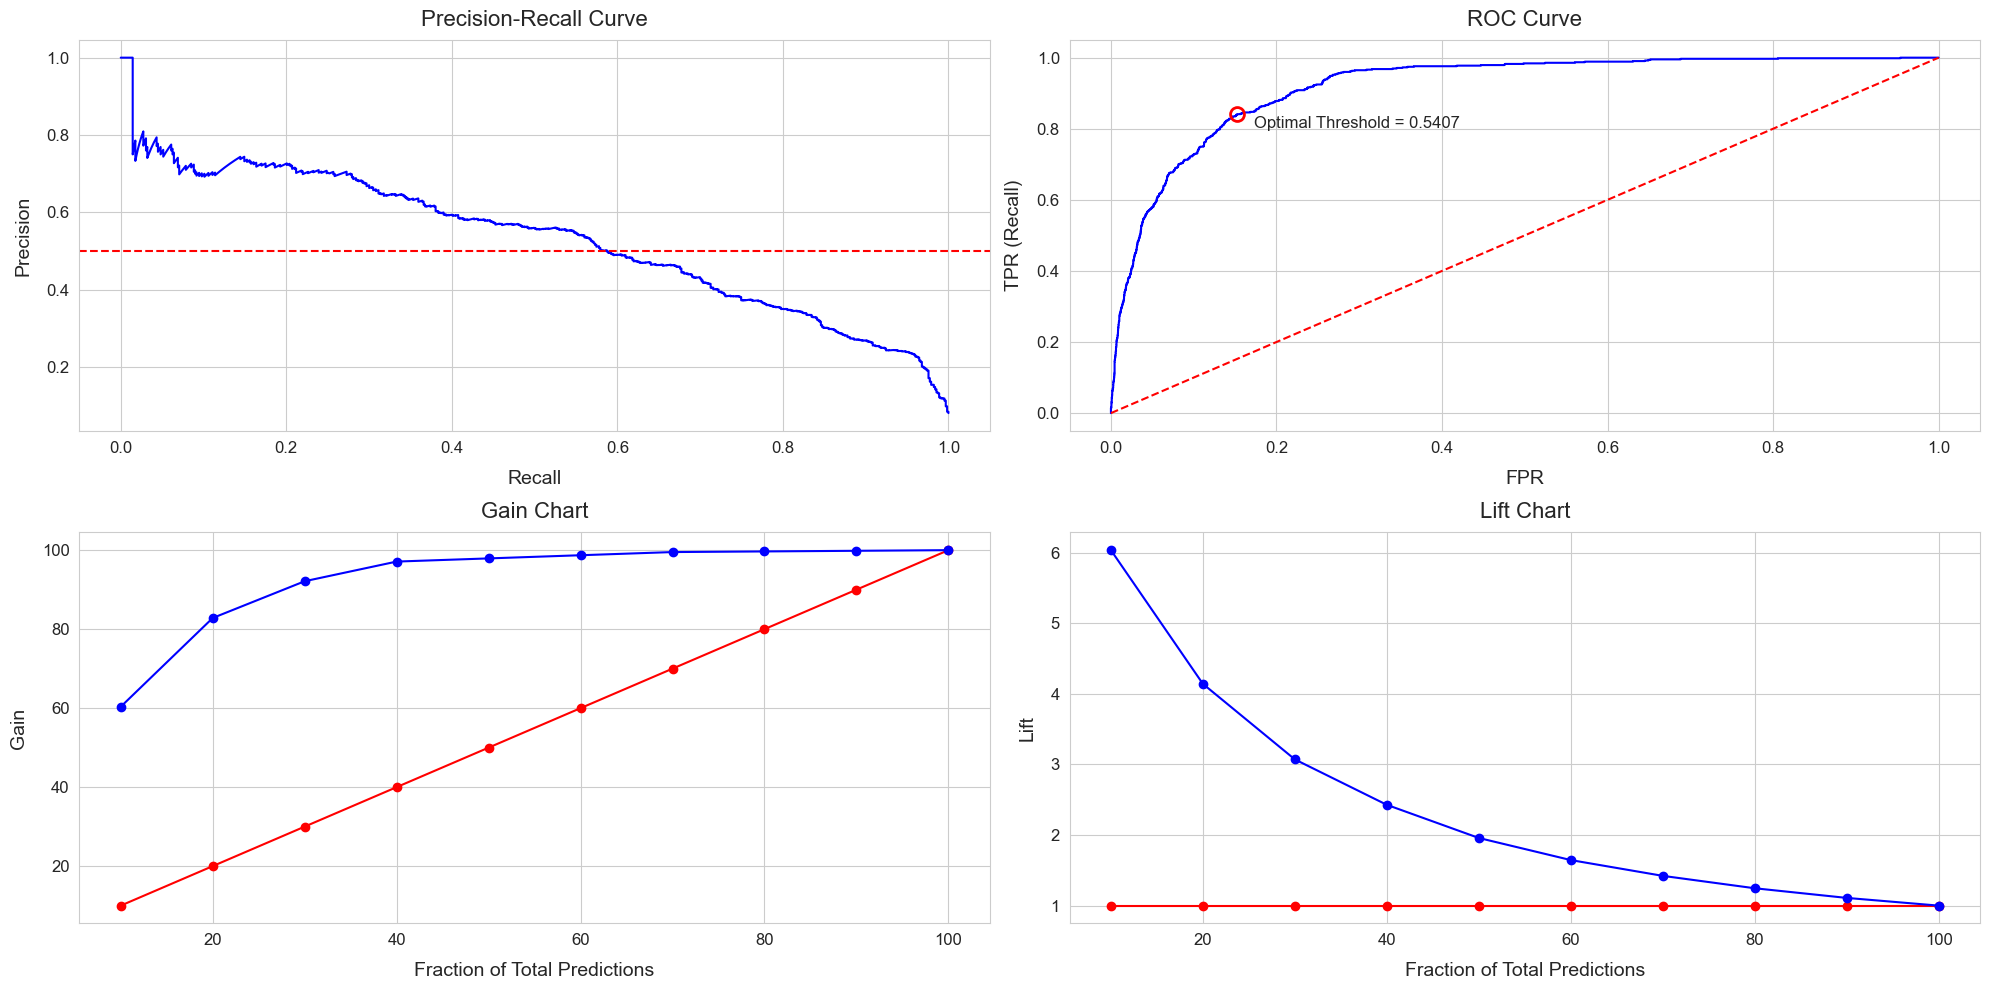

In [133]:
classification_evaluation_charts(ytest,lr_hyper_yhat_prob)

In [139]:
fpr,tpr,threshold_roc = roc_curve(ytest,lr_hyper_yhat_prob)
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_roc = threshold_roc[optimal_idx]

lr_opth = (lr_hyper_yhat_prob > optimal_threshold_roc).astype(int)

In [140]:
lr_metrics_50 = [precision_score(ytest,lr_hyper_yhat).round(2),
                 recall_score(ytest,lr_hyper_yhat).round(2),
                 f1_score(ytest,lr_hyper_yhat).round(2),
                 roc_auc_score(ytest,lr_hyper_yhat).round(2),
                 log_loss(ytest,lr_hyper_yhat).round(2),
                 matthews_corrcoef(ytest,lr_hyper_yhat).round(2)]

lr_metrics_opth = [precision_score(ytest,lr_opth).round(2),
                   recall_score(ytest,lr_opth).round(2),
                   f1_score(ytest,lr_opth).round(2),
                   roc_auc_score(ytest,lr_opth).round(2),
                   log_loss(ytest,lr_opth).round(2),
                   matthews_corrcoef(ytest,lr_opth).round(2)]

In [141]:
lr_metrics = pd.DataFrame(index=['Precision','Recall','F1','AUC','Log-Loss','Matthews-CorrCoef'],columns=['0.5 Threshold','Optimum Threshold'])
lr_metrics['0.5 Threshold'] = lr_metrics_50
lr_metrics['Optimum Threshold'] = lr_metrics_opth
lr_metrics

,0.5 Threshold,Optimum Threshold
Precision,0.30,0.33
Recall,0.85,0.84
F1,0.45,0.47
AUC,0.84,0.84
Log-Loss,6.22,5.53
Matthews-CorrCoef,0.44,0.46


In [142]:
print('Classification Report for Logistic Regression \n')

print('\t\t\t 0.5 Threshold \n')
print(classification_report(ytest,lr_hyper_yhat))

print('\t\t\t Optimum Threshold \n')
print(classification_report(ytest,lr_opth))

Classification Report for Logistic Regression 

			 0.5 Threshold 

              precision    recall  f1-score   support

           0       0.98      0.83      0.90      7020
           1       0.30      0.85      0.45       623

    accuracy                           0.83      7643
   macro avg       0.64      0.84      0.67      7643
weighted avg       0.93      0.83      0.86      7643

			 Optimum Threshold 

              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7020
           1       0.33      0.84      0.47       623

    accuracy                           0.85      7643
   macro avg       0.66      0.84      0.69      7643
weighted avg       0.93      0.85      0.87      7643



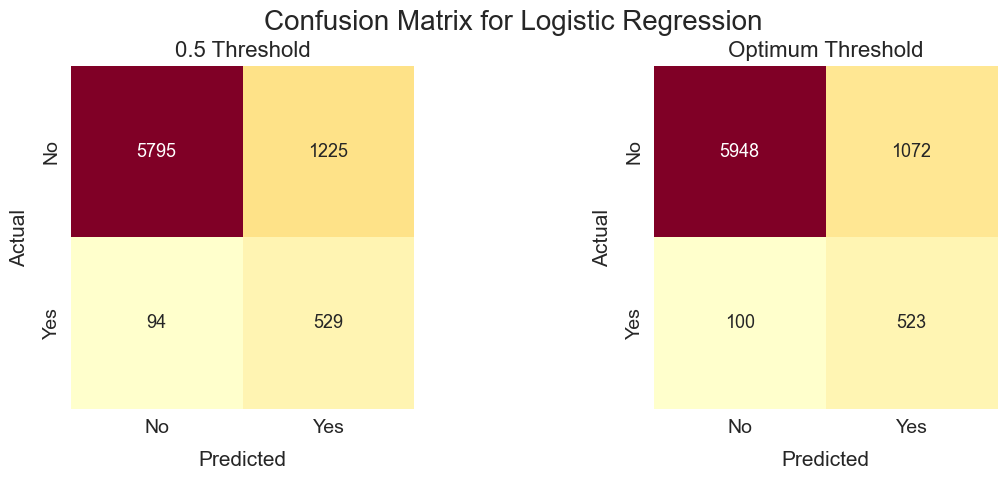

In [143]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
plt.suptitle('Confusion Matrix for Logistic Regression',y=0.95,fontsize=20)

sns.heatmap(confusion_matrix(ytest,lr_hyper_yhat),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
            xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[0])
ax[0].set_title('0.5 Threshold',size=16)
ax[0].set_xlabel('Predicted',labelpad=10,size=15)
ax[0].set_ylabel('Actual',labelpad=10,size=15)
ax[0].tick_params(axis='both',labelsize=14);

sns.heatmap(confusion_matrix(ytest,lr_opth),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
            xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[1])
ax[1].set_title('Optimum Threshold',size=16)
ax[1].set_xlabel('Predicted',labelpad=10,size=15)
ax[1].set_ylabel('Actual',labelpad=10,size=15)
ax[1].tick_params(axis='both',labelsize=14);

plt.tight_layout()

#### KNeighbors

In [147]:
from sklearn.neighbors import KNeighborsClassifier

In [148]:
knn_pipe = make_pipeline(preprocessor,KNeighborsClassifier(n_jobs=-1))

knn_params = {'kneighborsclassifier__n_neighbors':[25,50,75,100,125],
              'kneighborsclassifier__weights':['uniform','distance'],
              'kneighborsclassifier__p':[1,2]}

knn_rand = RandomizedSearchCV(knn_pipe,knn_params,scoring='roc_auc',n_jobs=-1,cv=5,random_state=42)
knn_rand.fit(Xtrain,ytrain)

knn_yhat = knn_rand.predict(Xtest)
knn_yhat_prob = knn_rand.predict_proba(Xtest)[:,1]

print('Randomized Search CV Results')
print(f'Best Score: {knn_rand.best_score_:0.2f}')
print(f'Best Parameter Space: {knn_rand.best_params_}')

print('Test Set Results')
print(f'ROC AUC Score: {roc_auc_score(ytest,knn_yhat):0.2f}')

Randomized Search CV Results
Best Score: 0.94
Best Parameter Space: {'kneighborsclassifier__weights': 'uniform', 'kneighborsclassifier__p': 2, 'kneighborsclassifier__n_neighbors': 125}
Test Set Results
ROC AUC Score: 0.67


In [149]:
knn_space = {'n_neighbors': hp.randint('n_neighbors',1,200),
             'weights': hp.choice('weights',['uniform','distance']),
             'p': hp.choice('p',[1,2])}

def knn_objective(space):
    
    model = Pipeline([('preprocessor',preprocessor),('knn',KNeighborsClassifier(n_jobs=-1,**space))])
    
    model.fit(Xtrain,ytrain)
    ypred = model.predict(Xtest)
    roc_auc = roc_auc_score(ytest,ypred).round(2)
    loss = (1 - roc_auc).round(2)
    
    return {'loss':loss,'status':STATUS_OK,'model':model}

knn_trials = Trials()
knn_hyper = fmin(fn=knn_objective,space=knn_space,algo=tpe.suggest,max_evals=20,trials=knn_trials)

print('Hyperopt Search Results')
print('Best Parameter Space:', knn_hyper)
print(f'Best Score:', 1 - knn_trials.best_trial['result']['loss'])

search_knn_hyper = knn_trials.best_trial['result']['model']
knn_hyper_yhat = search_knn_hyper.predict(Xtest)
knn_hyper_yhat_prob = search_knn_hyper.predict_proba(Xtest)[:,1]
print('Test Set Results')
print(f'ROC AUC Score: {roc_auc_score(ytest,knn_hyper_yhat):0.2f}')

100%|██████████| 20/20 [00:07<00:00,  2.58trial/s, best loss: 0.29]
Hyperopt Search Results
Best Parameter Space: {'n_neighbors': 115, 'p': 1, 'weights': 1}
Best Score: 0.71
Test Set Results
ROC AUC Score: 0.71


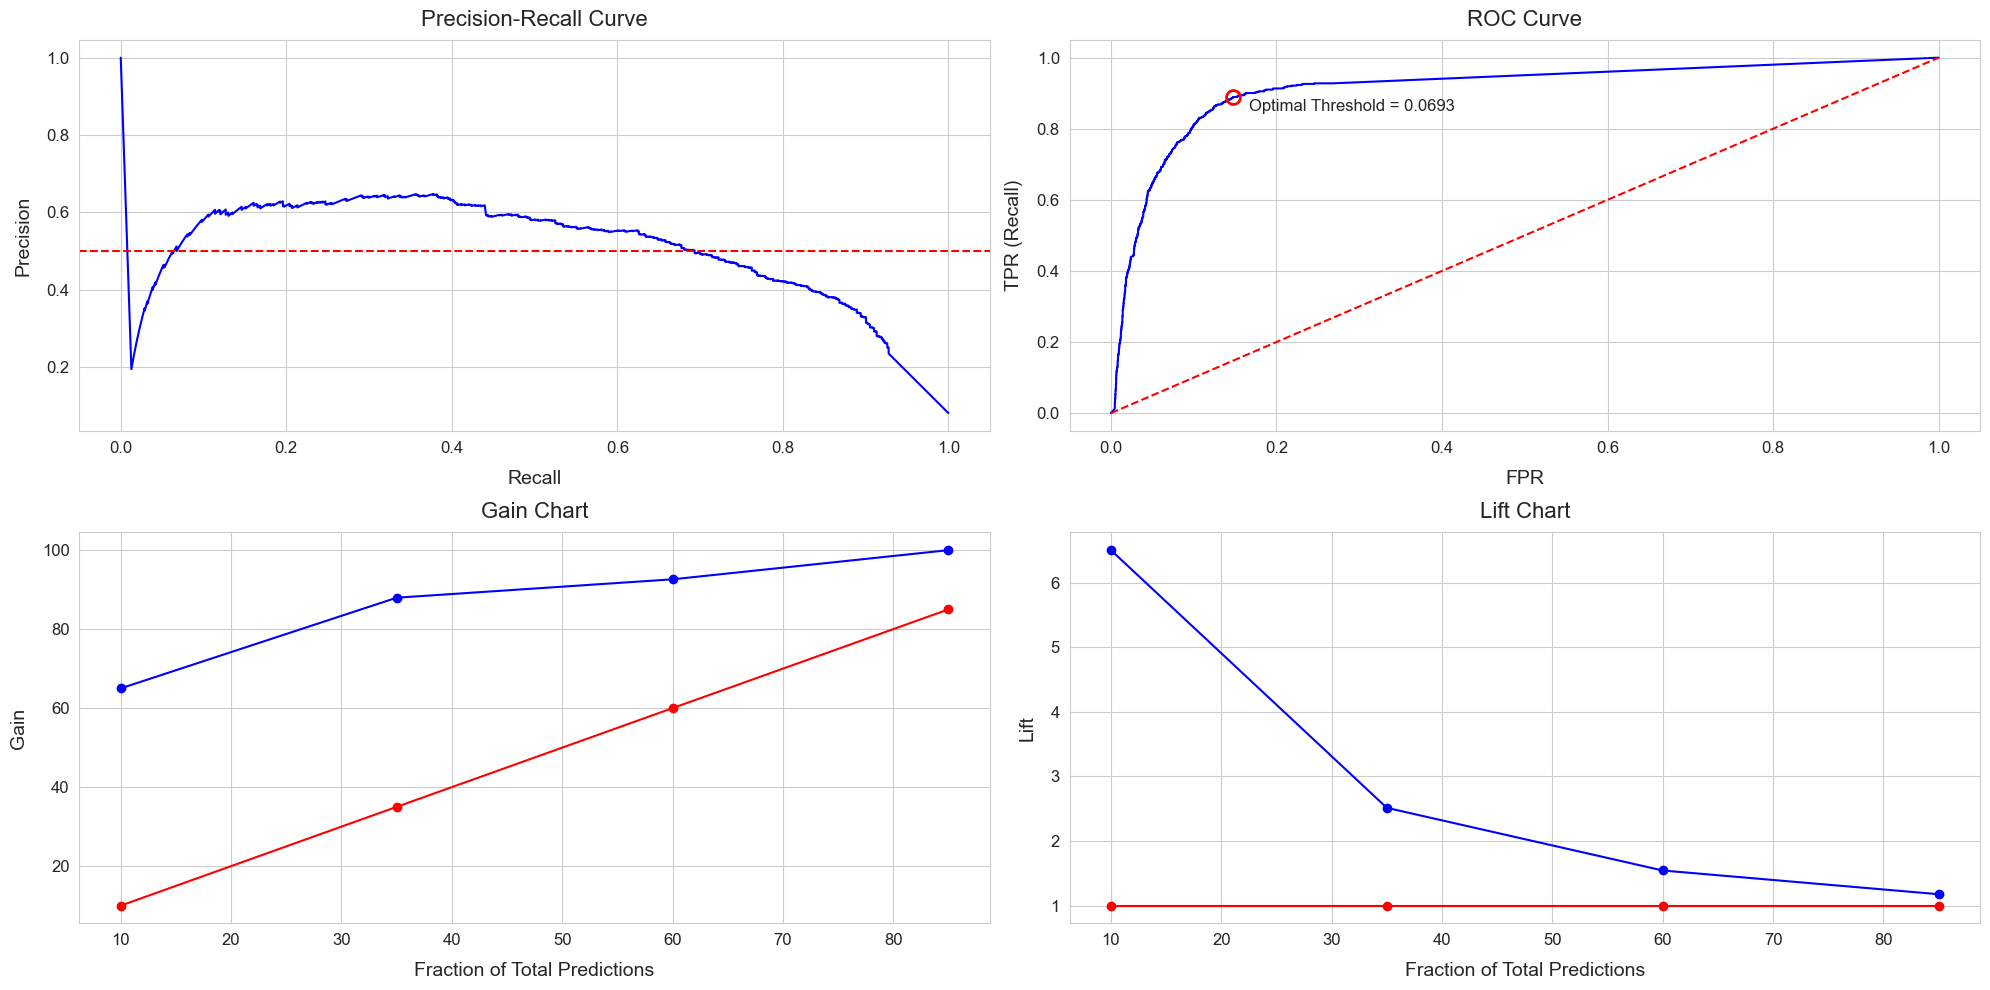

In [150]:
classification_evaluation_charts(ytest,knn_hyper_yhat_prob)

In [151]:
fpr,tpr,threshold_roc = roc_curve(ytest,knn_hyper_yhat_prob)
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_roc = threshold_roc[optimal_idx]

knn_opth = (knn_hyper_yhat_prob > optimal_threshold_roc).astype(int)

In [152]:
knn_metrics_50 = [precision_score(ytest,knn_hyper_yhat).round(2),
                  recall_score(ytest,knn_hyper_yhat).round(2),
                  f1_score(ytest,knn_hyper_yhat).round(2),
                  roc_auc_score(ytest,knn_hyper_yhat).round(2),
                  log_loss(ytest,knn_hyper_yhat).round(2),
                  matthews_corrcoef(ytest,knn_hyper_yhat).round(2)]

knn_metrics_opth = [precision_score(ytest,knn_opth).round(2),
                    recall_score(ytest,knn_opth).round(2),
                    f1_score(ytest,knn_opth).round(2),
                    roc_auc_score(ytest,knn_opth).round(2),
                    log_loss(ytest,knn_opth).round(2),
                    matthews_corrcoef(ytest,knn_opth).round(2)]

In [153]:
knn_metrics = pd.DataFrame(index=['Precision','Recall','F1','AUC','Log-Loss','Matthews-CorrCoef'],columns=['0.5 Threshold','Optimum Threshold'])
knn_metrics['0.5 Threshold'] = knn_metrics_50
knn_metrics['Optimum Threshold'] = knn_metrics_opth
knn_metrics

,0.5 Threshold,Optimum Threshold
Precision,0.62,0.35
Recall,0.44,0.89
F1,0.51,0.50
AUC,0.71,0.87
Log-Loss,2.45,5.20
Matthews-CorrCoef,0.49,0.50


In [154]:
print('Classification Report for KNeighbors \n')

print('\t\t\t 0.5 Threshold \n')
print(classification_report(ytest,knn_hyper_yhat))

print('\t\t\t Optimum Threshold \n')
print(classification_report(ytest,knn_opth))

Classification Report for KNeighbors 

			 0.5 Threshold 

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7020
           1       0.62      0.44      0.51       623

    accuracy                           0.93      7643
   macro avg       0.78      0.71      0.74      7643
weighted avg       0.92      0.93      0.93      7643

			 Optimum Threshold 

              precision    recall  f1-score   support

           0       0.99      0.85      0.92      7020
           1       0.35      0.89      0.50       623

    accuracy                           0.86      7643
   macro avg       0.67      0.87      0.71      7643
weighted avg       0.94      0.86      0.88      7643



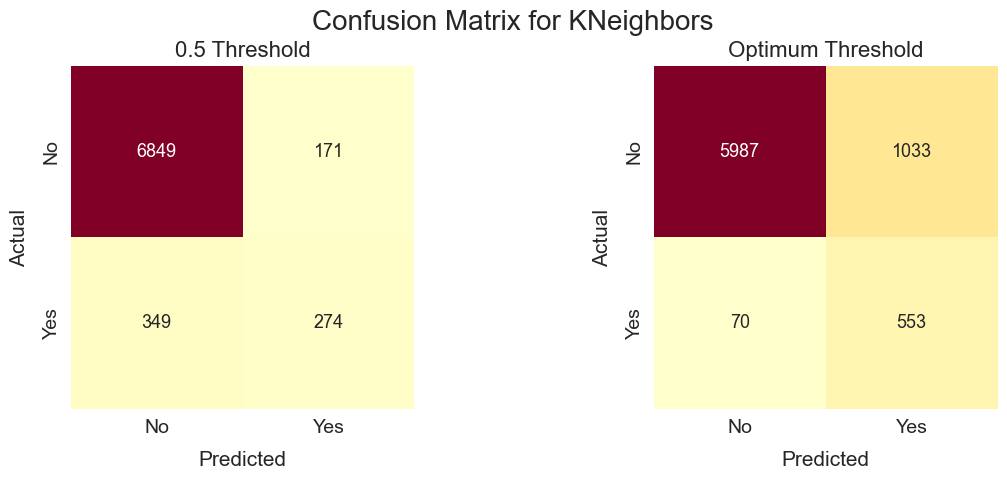

In [155]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
plt.suptitle('Confusion Matrix for KNeighbors',y=0.95,fontsize=20)

sns.heatmap(confusion_matrix(ytest,knn_hyper_yhat),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
            xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[0])
ax[0].set_title('0.5 Threshold',size=16)
ax[0].set_xlabel('Predicted',labelpad=10,size=15)
ax[0].set_ylabel('Actual',labelpad=10,size=15)
ax[0].tick_params(axis='both',labelsize=14);

sns.heatmap(confusion_matrix(ytest,knn_opth),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
            xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[1])
ax[1].set_title('Optimum Threshold',size=16)
ax[1].set_xlabel('Predicted',labelpad=10,size=15)
ax[1].set_ylabel('Actual',labelpad=10,size=15)
ax[1].tick_params(axis='both',labelsize=14);

plt.tight_layout()

#### Support Vector Machine

In [156]:
from sklearn.svm import LinearSVC,SVC

In [157]:
svm_pipe = make_pipeline(preprocessor,LinearSVC(penalty='l2',loss='hinge',dual='auto',class_weight=class_wt,random_state=42))

svm_params = {'linearsvc__C':[0.001,0.01,0.1,1,10,100]}

svm_rand = RandomizedSearchCV(svm_pipe,svm_params,scoring='roc_auc',n_jobs=-1,cv=5,random_state=42)
svm_rand.fit(Xtrain,ytrain)

svm_yhat = svm_rand.predict(Xtest)
# svm_yhat_prob = svm_rand.predict_proba(Xtest)[:,1]

print('Randomized Search CV Results')
print(f'Best Score: {svm_rand.best_score_:0.2f}')
print(f'Best Parameter Space: {svm_rand.best_params_}')

print('Test Set Results')
print(f'ROC AUC Score: {roc_auc_score(ytest,svm_yhat):0.2f}')

Randomized Search CV Results
Best Score: 0.92
Best Parameter Space: {'linearsvc__C': 1}
Test Set Results
ROC AUC Score: 0.84


In [158]:
svm_pipe = Pipeline([('preprocessor',preprocessor),('svc',SVC(kernel='linear',probability=True,class_weight=class_wt,random_state=42))])

svm_params = {'svc__C':[0.01,0.1,1,10]}

svm_rand = RandomizedSearchCV(svm_pipe,svm_params,scoring='roc_auc',n_jobs=-1,cv=5,random_state=42)
svm_rand.fit(Xtrain,ytrain)

svm_yhat = svm_rand.predict(Xtest)
svm_yhat_prob = svm_rand.predict_proba(Xtest)[:,1]

print('Randomized Search CV Results')
print(f'Best Score: {svm_rand.best_score_:0.2f}')
print(f'Best Parameter Space: {svm_rand.best_params_}')

print('Test Set Results')
print(f'ROC AUC Score: {roc_auc_score(ytest,svm_yhat):0.2f}')

In [41]:
svm_space = {'C': hp.uniform('C',0.001,100)}

def svm_objective(space):
    
    model = Pipeline([('preprocessor',preprocessor),('svc',SVC(kernel='linear',probability=True,class_weight=class_wt,random_state=42))])
    
    model.fit(Xtrain,ytrain)
    ypred = model.predict(Xtest)
    roc_auc = roc_auc_score(ytest,ypred).round(2)
    loss = (1 - roc_auc).round(2)
    
    return {'loss':loss,'status':STATUS_OK,'model':model}

svm_trials = Trials()
svm_hyper = fmin(fn=svm_objective,space=svm_space,algo=tpe.suggest,max_evals=20,trials=svm_trials)

print('Hyperopt Search Results')
print('Best Parameter Space:', svm_hyper)
print(f'Best Score:', 1 - svm_trials.best_trial['result']['loss'])

search_svm_hyper = svm_trials.best_trial['result']['model']
svm_hyper_yhat = search_svm_hyper.predict(Xtest)
svm_hyper_yhat_prob = search_svm_hyper.predict_proba(Xtest)[:,1]
print('Test Set Results')
print(f'ROC AUC Score: {roc_auc_score(ytest,svm_hyper_yhat)}')

100%|██████████| 20/20 [1:28:32<00:00, 265.64s/trial, best loss: 0.16] 
Hyperopt Search Results
Best Parameter Space: {'C': 20.403011088982847}
Best Score: 0.84
Test Set Results
ROC AUC Score: 0.8396737365838489


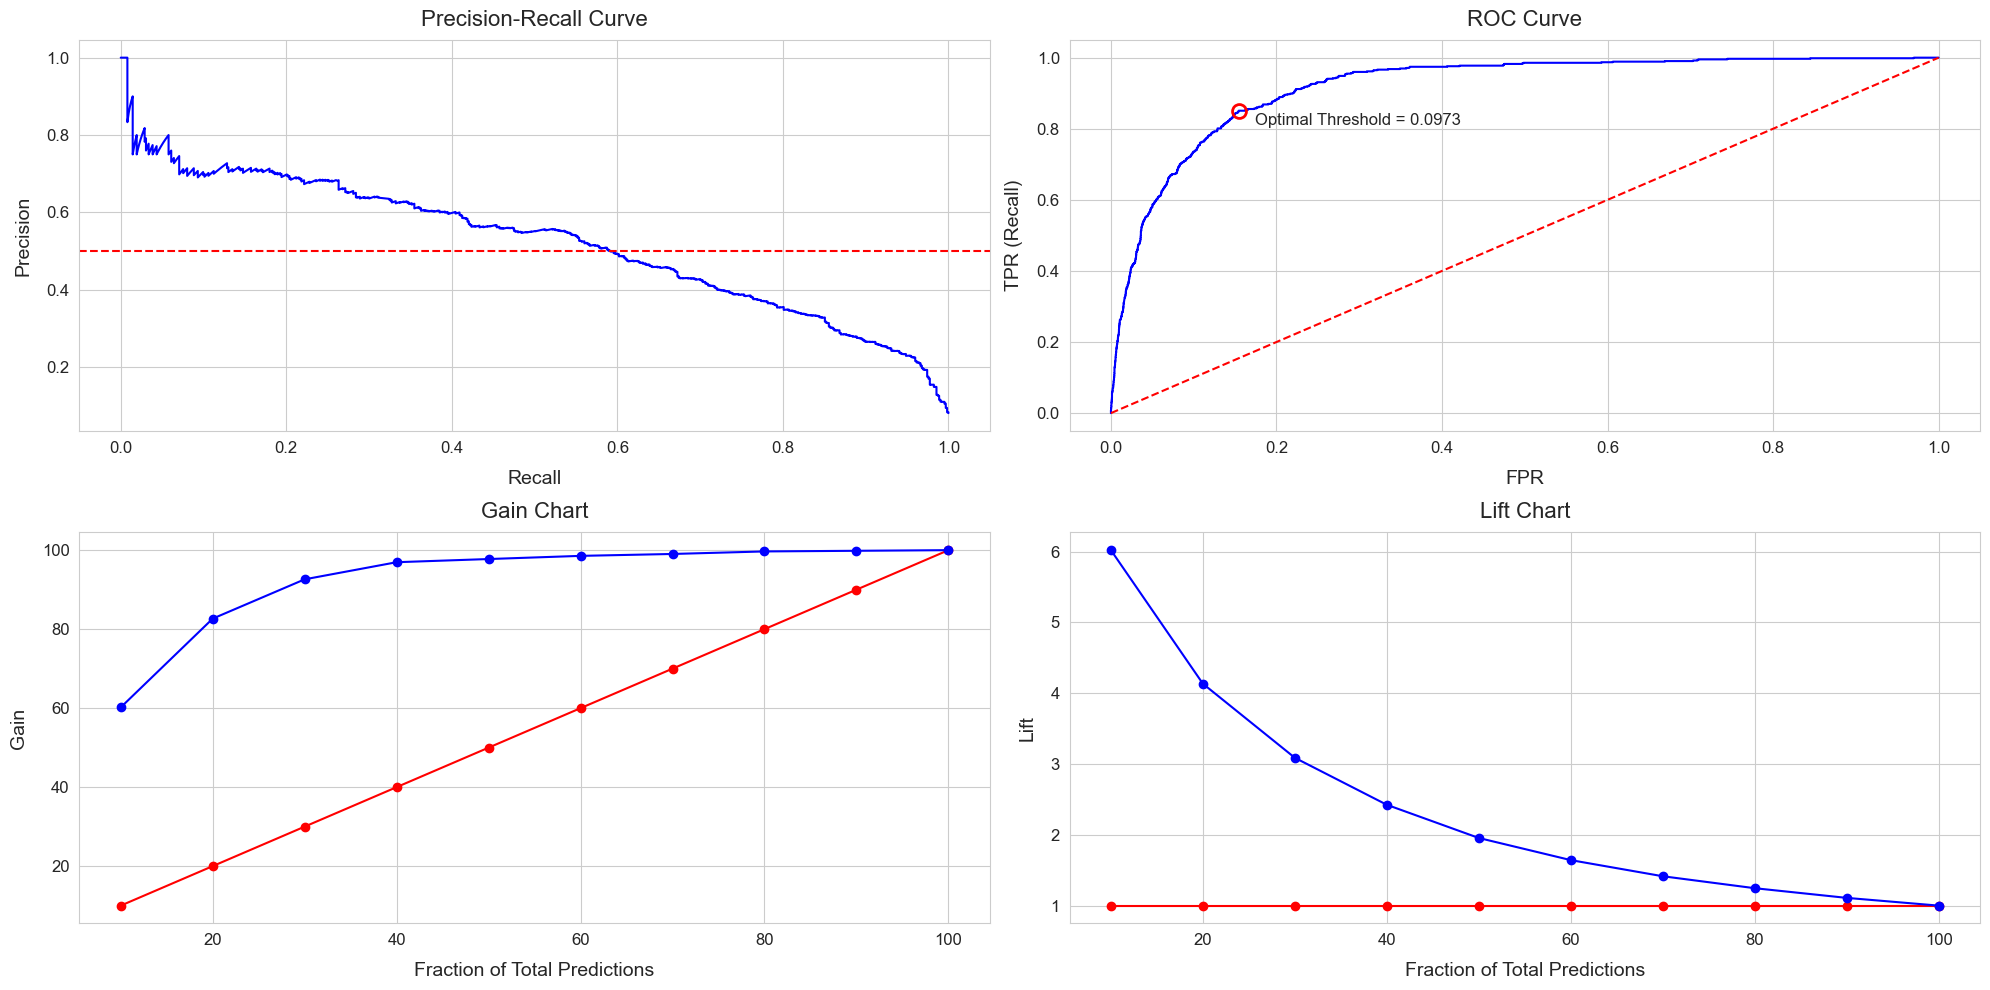

In [129]:
classification_evaluation_charts(ytest,svm_hyper_yhat_prob)

In [43]:
fpr,tpr,threshold_roc = roc_curve(ytest,svm_yhat_prob)
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_roc = threshold_roc[optimal_idx]

svm_opth = (svm_yhat_prob > optimal_threshold_roc).astype(int)

In [44]:
svm_metrics_50 = [precision_score(ytest,svm_yhat).round(2),
                 recall_score(ytest,svm_yhat).round(2),
                 f1_score(ytest,svm_yhat).round(2),
                 roc_auc_score(ytest,svm_yhat).round(2),
                 log_loss(ytest,svm_yhat).round(2),
                 matthews_corrcoef(ytest,svm_yhat).round(2)]

svm_metrics_opth = [precision_score(ytest,svm_opth).round(2),
                   recall_score(ytest,svm_opth).round(2),
                   f1_score(ytest,svm_opth).round(2),
                   roc_auc_score(ytest,svm_opth).round(2),
                   log_loss(ytest,svm_opth).round(2),
                   matthews_corrcoef(ytest,svm_opth).round(2)]

In [45]:
svm_metrics = pd.DataFrame(index=['Precision','Recall','F1','AUC','Log-Loss','Matthews-CorrCoef'],columns=['0.5 Threshold','Optimum Threshold'])
svm_metrics['0.5 Threshold'] = svm_metrics_50
svm_metrics['Optimum Threshold'] = svm_metrics_opth
svm_metrics

,0.5 Threshold,Optimum Threshold
Precision,0.29,0.33
Recall,0.87,0.85
F1,0.43,0.47
AUC,0.84,0.85
Log-Loss,6.64,5.55
Matthews-CorrCoef,0.43,0.47


In [46]:
print('Classification Report for Support Vector Machine \n')

print('\t\t\t 0.5 Threshold \n')
print(classification_report(ytest,svm_yhat))

print('\t\t\t Optimum Threshold \n')
print(classification_report(ytest,svm_opth))

Classification Report for Support Vector Machine 

			 0.5 Threshold 

              precision    recall  f1-score   support

           0       0.99      0.81      0.89      7020
           1       0.29      0.87      0.43       623

    accuracy                           0.82      7643
   macro avg       0.64      0.84      0.66      7643
weighted avg       0.93      0.82      0.85      7643

			 Optimum Threshold 

              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7020
           1       0.33      0.85      0.47       623

    accuracy                           0.85      7643
   macro avg       0.66      0.85      0.69      7643
weighted avg       0.93      0.85      0.87      7643



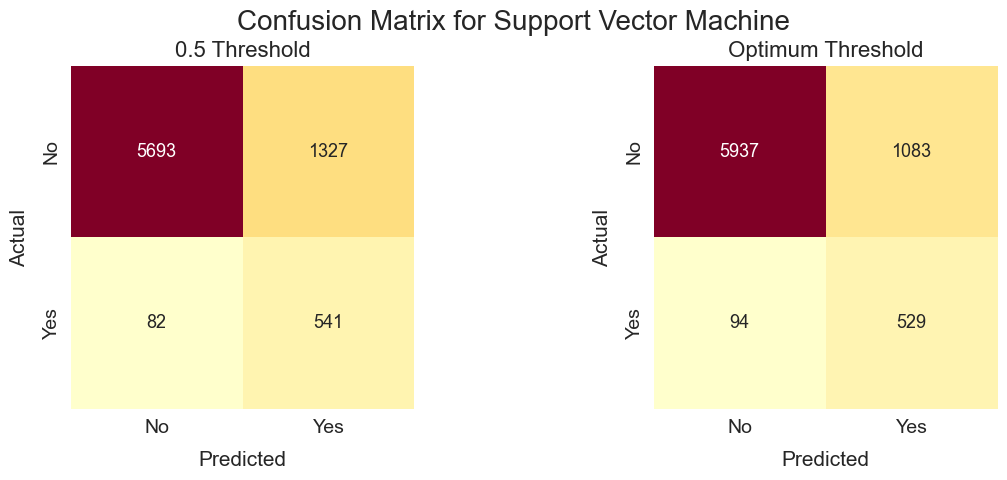

In [47]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
plt.suptitle('Confusion Matrix for Support Vector Machine',y=0.95,fontsize=20)

sns.heatmap(confusion_matrix(ytest,svm_yhat),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
            xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[0])
ax[0].set_title('0.5 Threshold',size=16)
ax[0].set_xlabel('Predicted',labelpad=10,size=15)
ax[0].set_ylabel('Actual',labelpad=10,size=15)
ax[0].tick_params(axis='both',labelsize=14);

sns.heatmap(confusion_matrix(ytest,svm_opth),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
            xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[1])
ax[1].set_title('Optimum Threshold',size=16)
ax[1].set_xlabel('Predicted',labelpad=10,size=15)
ax[1].set_ylabel('Actual',labelpad=10,size=15)
ax[1].tick_params(axis='both',labelsize=14);

plt.tight_layout()

#### Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

Randomized Search CV Results
OOB Score: 0.87
Best Score: 0.95
Best Parameter Space: {'randomforestclassifier__n_estimators': 100, 'randomforestclassifier__max_depth': 9}
Test Set Results
ROC AUC Score: 0.89


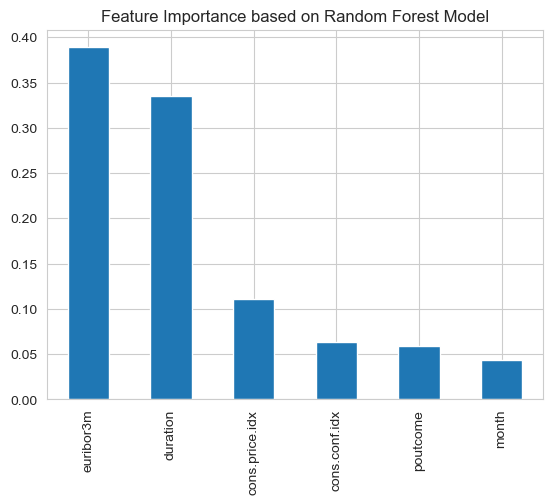

In [49]:
rf_pipe = make_pipeline(preprocessor,RandomForestClassifier(class_weight=class_wt,oob_score=True,random_state=42,n_jobs=-1))

rf_params = {'randomforestclassifier__n_estimators':[50,100,150,200],
             'randomforestclassifier__max_depth':[3,6,9,12]}

rf_rand = RandomizedSearchCV(rf_pipe,rf_params,scoring='roc_auc',n_jobs=-1,cv=5,random_state=42)
rf_rand.fit(Xtrain,ytrain)

print('Randomized Search CV Results')
print('OOB Score:',rf_rand.best_estimator_.named_steps['randomforestclassifier'].oob_score_.round(2))
print(f'Best Score: {rf_rand.best_score_:0.2f}')
print(f'Best Parameter Space: {rf_rand.best_params_}')

rf_yhat = rf_rand.predict(Xtest)
rf_yhat_prob = rf_rand.predict_proba(Xtest)[:,1]

print('Test Set Results')
print(f'ROC AUC Score: {roc_auc_score(ytest,rf_yhat):0.2f}')

rf_feature_imp = pd.Series(rf_rand.best_estimator_.named_steps['randomforestclassifier'].feature_importances_,index=feature_names)
rf_feature_imp.sort_values(ascending=False).plot(kind='bar',title='Feature Importance based on Random Forest Model');

100%|██████████| 20/20 [00:19<00:00,  1.04trial/s, best loss: 0.27]
Hyperopt Search Results
Best Parameter Space: {'max_depth': 20, 'n_neighbors': 310}
Best Score: 0.73
OOB Score: 0.92
Test Set Results
ROC AUC Score: 0.73


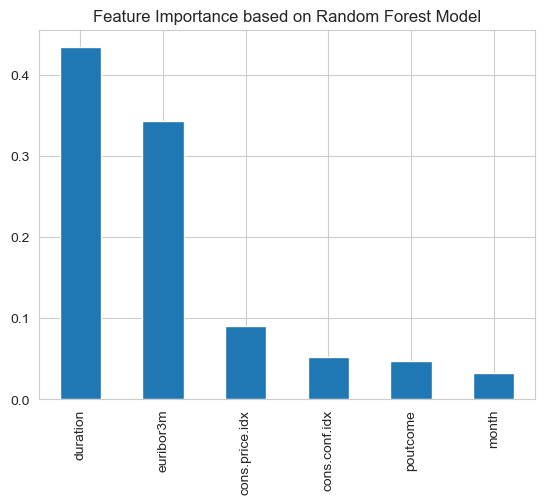

In [50]:
rf_space = {'n_neighbors': hp.randint('n_neighbors',1,500),
            'max_depth':hp.randint('max_depth',1,50)}

def rf_objective(space):
    
    model = Pipeline([('preprocessor',preprocessor),('rfc',RandomForestClassifier(class_weight=class_wt,oob_score=True,random_state=42,n_jobs=-1))])
    
    model.fit(Xtrain,ytrain)
    ypred = model.predict(Xtest)
    roc_auc = roc_auc_score(ytest,ypred).round(2)
    loss = (1 - roc_auc).round(2)
    
    return {'loss':loss,'status':STATUS_OK,'model':model}

rf_trials = Trials()
rf_hyper = fmin(fn=rf_objective,space=rf_space,algo=tpe.suggest,max_evals=20,trials=rf_trials)

print('Hyperopt Search Results')
print('Best Parameter Space:',rf_hyper)
print(f'Best Score:', 1 - rf_trials.best_trial['result']['loss'])
search_rf_hyper = rf_trials.best_trial['result']['model']
print('OOB Score:',search_rf_hyper.named_steps['rfc'].oob_score_.round(2))

rf_hyper_yhat = search_rf_hyper.predict(Xtest)
print('Test Set Results')
print(f'ROC AUC Score: {roc_auc_score(ytest,rf_hyper_yhat):0.2f}')

rf_hyper_feature_imp = pd.Series(search_rf_hyper.named_steps['rfc'].feature_importances_,index=feature_names)
rf_hyper_feature_imp.sort_values(ascending=False).plot(kind='bar',title='Feature Importance based on Random Forest Model');

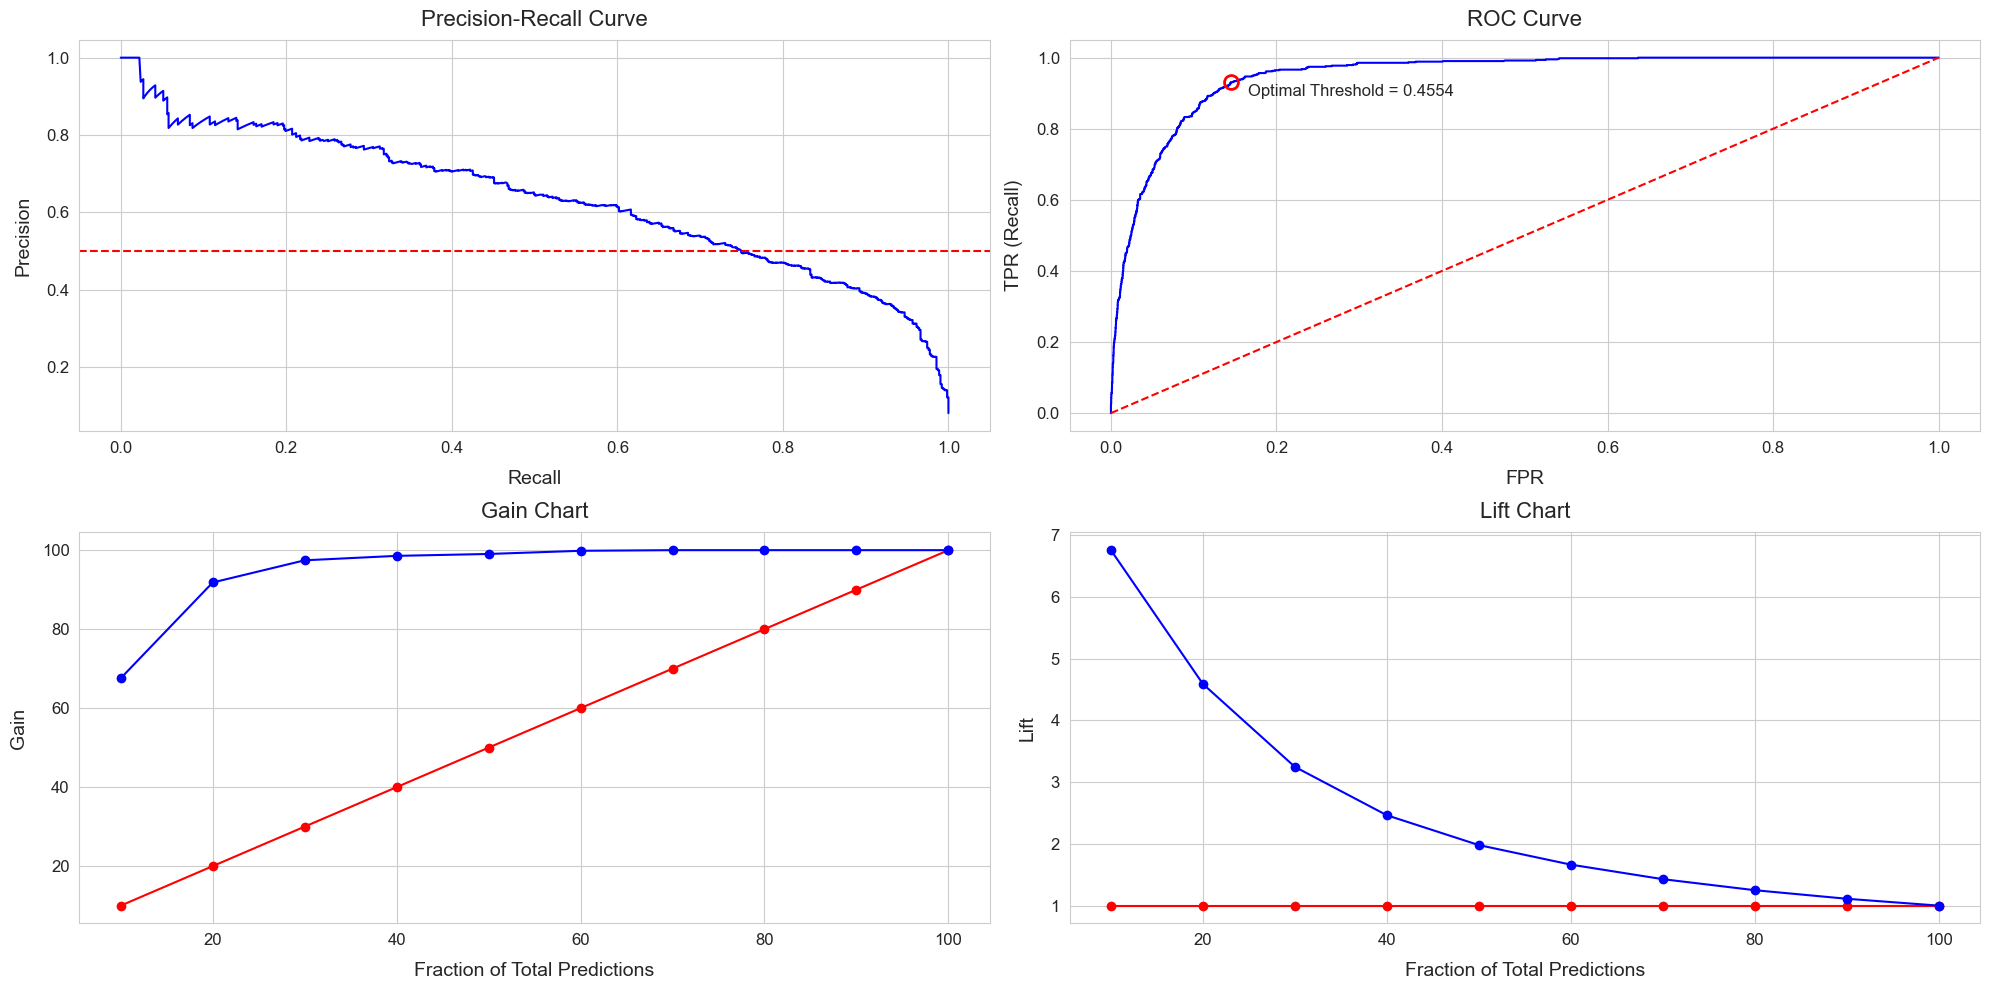

In [51]:
classification_evaluation_charts(ytest,rf_yhat_prob)

In [52]:
fpr,tpr,threshold_roc = roc_curve(ytest,rf_yhat_prob)
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_roc = threshold_roc[optimal_idx]

rf_opth = (rf_yhat_prob > optimal_threshold_roc).astype(int)

In [53]:
rf_metrics_50 = [precision_score(ytest,rf_yhat).round(2),
                 recall_score(ytest,rf_yhat).round(2),
                 f1_score(ytest,rf_yhat).round(2),
                 roc_auc_score(ytest,rf_yhat).round(2),
                 log_loss(ytest,rf_yhat).round(2),
                 matthews_corrcoef(ytest,rf_yhat).round(2)]

rf_metrics_opth = [precision_score(ytest,rf_opth).round(2),
                   recall_score(ytest,rf_opth).round(2),
                   f1_score(ytest,rf_opth).round(2),
                   roc_auc_score(ytest,rf_opth).round(2),
                   log_loss(ytest,rf_opth).round(2),
                   matthews_corrcoef(ytest,rf_opth).round(2)]

In [54]:
rf_metrics = pd.DataFrame(index=['Precision','Recall','F1','AUC','Log-Loss','Matthews-CorrCoef'],columns=['0.5 Threshold','Optimum Threshold'])
rf_metrics['0.5 Threshold'] = rf_metrics_50
rf_metrics['Optimum Threshold'] = rf_metrics_opth
rf_metrics

,0.5 Threshold,Optimum Threshold
Precision,0.38,0.36
Recall,0.91,0.93
F1,0.54,0.52
AUC,0.89,0.89
Log-Loss,4.59,5.01
Matthews-CorrCoef,0.54,0.53


In [55]:
print('Classification Report for Random Forest \n')

print('\t\t\t 0.5 Threshold \n')
print(classification_report(ytest,rf_yhat))

print('\t\t\t Optimum Threshold \n')
print(classification_report(ytest,rf_opth))

Classification Report for Random Forest 

			 0.5 Threshold 

              precision    recall  f1-score   support

           0       0.99      0.87      0.93      7020
           1       0.38      0.91      0.54       623

    accuracy                           0.87      7643
   macro avg       0.69      0.89      0.73      7643
weighted avg       0.94      0.87      0.89      7643

			 Optimum Threshold 

              precision    recall  f1-score   support

           0       0.99      0.85      0.92      7020
           1       0.36      0.93      0.52       623

    accuracy                           0.86      7643
   macro avg       0.68      0.89      0.72      7643
weighted avg       0.94      0.86      0.89      7643



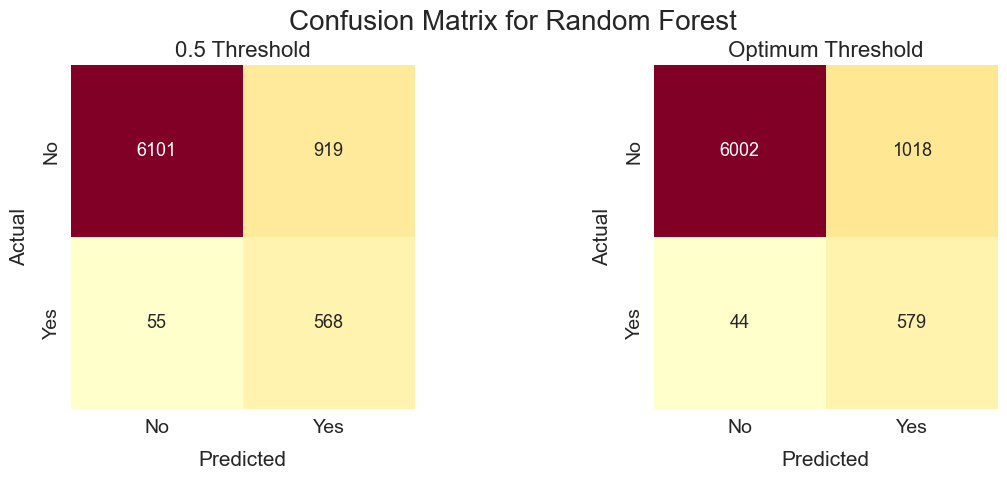

In [56]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
plt.suptitle('Confusion Matrix for Random Forest',y=0.95,fontsize=20)

sns.heatmap(confusion_matrix(ytest,rf_yhat),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
            xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[0])
ax[0].set_title('0.5 Threshold',size=16)
ax[0].set_xlabel('Predicted',labelpad=10,size=15)
ax[0].set_ylabel('Actual',labelpad=10,size=15)
ax[0].tick_params(axis='both',labelsize=14);

sns.heatmap(confusion_matrix(ytest,rf_opth),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
            xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[1])
ax[1].set_title('Optimum Threshold',size=16)
ax[1].set_xlabel('Predicted',labelpad=10,size=15)
ax[1].set_ylabel('Actual',labelpad=10,size=15)
ax[1].tick_params(axis='both',labelsize=14);

plt.tight_layout()

#### XGBoost

In [57]:
from xgboost import XGBClassifier

Randomized Search CV Results
Best Score: 0.95
Best Parameter Space: {'xgbclassifier__reg_lambda': 0.01, 'xgbclassifier__reg_alpha': 0.001, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__max_depth': 6, 'xgbclassifier__gamma': 10, 'xgbclassifier__eta': 0.3}
Test Set Results
ROC AUC Score: 0.72


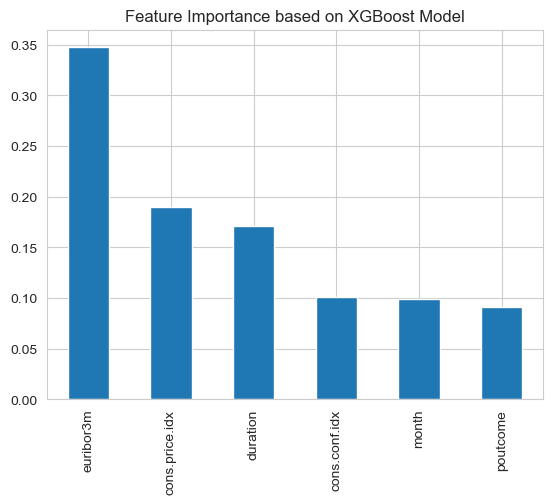

In [58]:
xgb_pipe = make_pipeline(preprocessor,XGBClassifier(random_state=42,n_jobs=-1))

xgb_params = {'xgbclassifier__n_estimators':[50,100,150,200],
              'xgbclassifier__max_depth':[3,6,9,12],
              'xgbclassifier__eta':[0.2,0.25,0.3,0.35],
              'xgbclassifier__gamma':[1,10,100],
              'xgbclassifier__reg_lambda':[0.001,0.01,0.1,0,1,10,100],
              'xgbclassifier__reg_alpha':[0.001,0.01,0.1,0,1,10,100]}

xgb_rand = RandomizedSearchCV(xgb_pipe,xgb_params,scoring='roc_auc',n_jobs=-1,cv=5,random_state=42)
xgb_rand.fit(Xtrain,ytrain)

print('Randomized Search CV Results')
print(f'Best Score: {xgb_rand.best_score_:0.2f}')
print(f'Best Parameter Space: {xgb_rand.best_params_}')

xgb_yhat = xgb_rand.predict(Xtest)
xgb_yhat_prob = xgb_rand.predict_proba(Xtest)[:,1]

print('Test Set Results')
print(f'ROC AUC Score: {roc_auc_score(ytest,xgb_yhat):0.2f}')

xgb_feature_imp = pd.Series(xgb_rand.best_estimator_.named_steps['xgbclassifier'].feature_importances_,index=feature_names)
xgb_feature_imp.sort_values(ascending=False).plot(kind='bar',title='Feature Importance based on XGBoost Model');

100%|██████████| 20/20 [00:38<00:00,  1.91s/trial, best loss: 0.26]
Hyperopt Search Results
Best Parameter Space: {'colsample_bytree': 0.8398703978845983, 'gamma': 1.5433214575090286, 'learning_rate': 0.21767460357548413, 'max_depth': 44, 'min_child_weight': 2, 'n_estimators': 310, 'reg_alpha': 2.0643959424934604, 'reg_lambda': 4.791699782642578, 'subsample': 0.5987955851438225}
Best Score: 0.74
Test Set Results
ROC AUC Score: 0.74


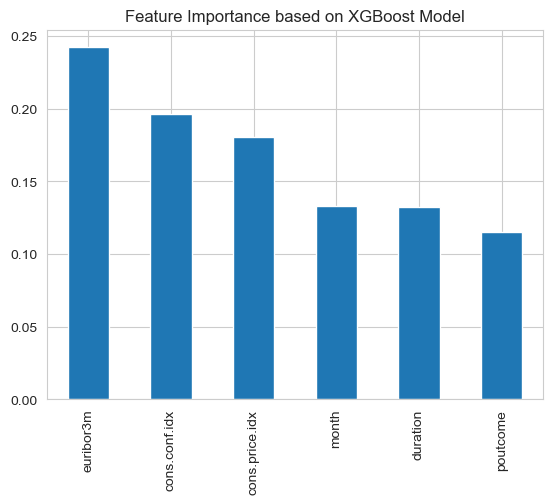

In [59]:
xgb_space = {'n_estimators': hp.randint('n_estimators',1,500),
             'max_depth':hp.randint('max_depth',1,50),
             'learning_rate': hp.uniform('learning_rate',0.01,0.3),
             'subsample': hp.uniform('subsample',0.5,1.0),
             'colsample_bytree': hp.uniform('colsample_bytree',0.5,1.0),
             'min_child_weight': hp.choice('min_child_weight',[1,3,5]),
             'gamma': hp.uniform('gamma',0,5),
             'reg_alpha': hp.uniform('reg_alpha',0.001,100),
             'reg_lambda': hp.uniform('reg_lambda',0.001,100)}

def xgb_objective(space):
    
    model = Pipeline([('preprocessor',preprocessor),('xgb',XGBClassifier(random_state=42,n_jobs=-1,**space))])
    
    model.fit(Xtrain,ytrain)
    ypred = model.predict(Xtest)
    roc_auc = roc_auc_score(ytest,ypred).round(2)
    loss = (1 - roc_auc).round(2)
    
    return {'loss':loss,'status':STATUS_OK,'model':model}

xgb_trials = Trials()
xgb_hyper = fmin(fn=xgb_objective,space=xgb_space,algo=tpe.suggest,max_evals=20,trials=xgb_trials)

print('Hyperopt Search Results')
print('Best Parameter Space:',xgb_hyper)
print(f'Best Score:', 1 - xgb_trials.best_trial['result']['loss'])
search_xgb_hyper = xgb_trials.best_trial['result']['model']

xgb_hyper_yhat = search_xgb_hyper.predict(Xtest)
print('Test Set Results')
print(f'ROC AUC Score: {roc_auc_score(ytest,xgb_hyper_yhat):0.2f}')

xgb_hyper_feature_imp = pd.Series(search_xgb_hyper.named_steps['xgb'].feature_importances_,index=feature_names)
xgb_hyper_feature_imp.sort_values(ascending=False).plot(kind='bar',title='Feature Importance based on XGBoost Model');

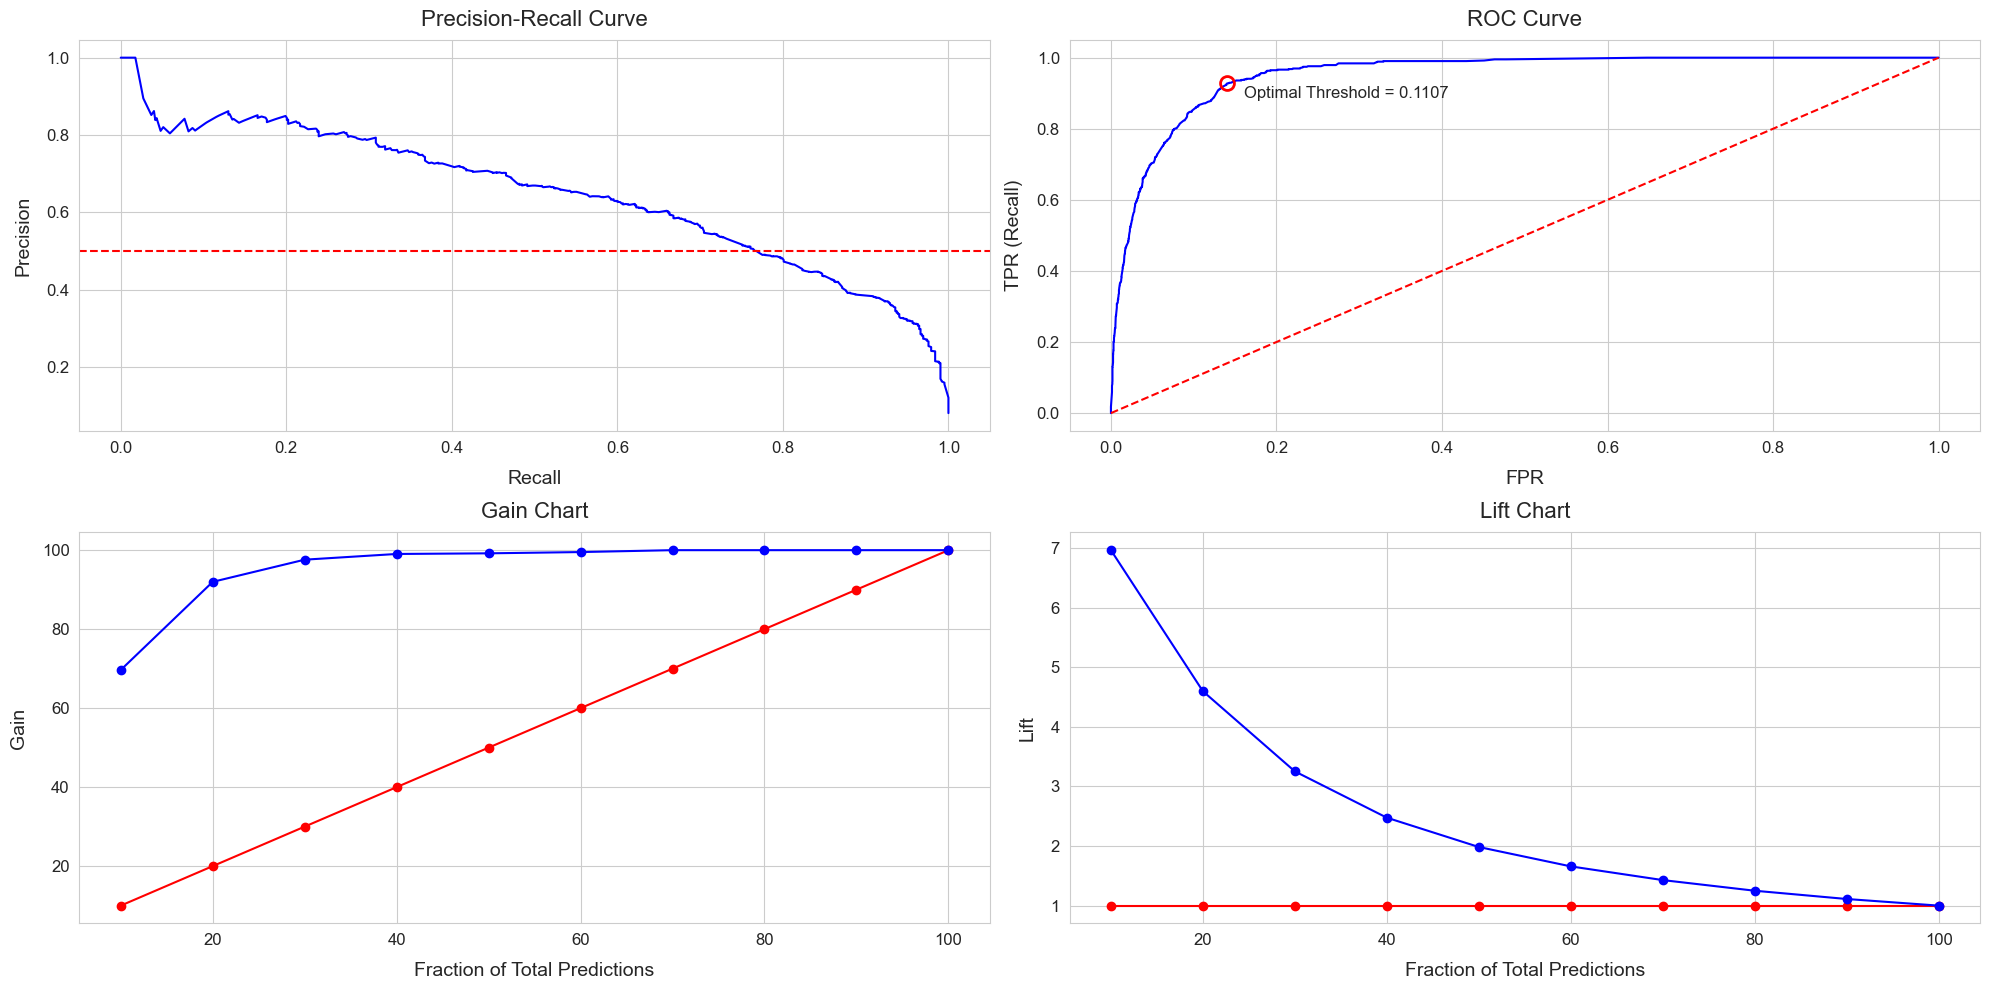

In [60]:
classification_evaluation_charts(ytest,xgb_yhat_prob)

In [61]:
fpr,tpr,threshold_roc = roc_curve(ytest,xgb_yhat_prob)
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_roc = threshold_roc[optimal_idx]

xgb_opth = (xgb_yhat_prob > optimal_threshold_roc).astype(int)

In [62]:
xgb_metrics_50 = [precision_score(ytest,xgb_yhat).round(2),
                 recall_score(ytest,xgb_yhat).round(2),
                 f1_score(ytest,xgb_yhat).round(2),
                 roc_auc_score(ytest,xgb_yhat).round(2),
                 log_loss(ytest,xgb_yhat).round(2),
                 matthews_corrcoef(ytest,xgb_yhat).round(2)]

xgb_metrics_opth = [precision_score(ytest,xgb_opth).round(2),
                   recall_score(ytest,xgb_opth).round(2),
                   f1_score(ytest,xgb_opth).round(2),
                   roc_auc_score(ytest,xgb_opth).round(2),
                   log_loss(ytest,xgb_opth).round(2),
                   matthews_corrcoef(ytest,xgb_opth).round(2)]

In [63]:
xgb_metrics = pd.DataFrame(index=['Precision','Recall','F1','AUC','Log-Loss','Matthews-CorrCoef'],columns=['0.5 Threshold','Optimum Threshold'])
xgb_metrics['0.5 Threshold'] = xgb_metrics_50
xgb_metrics['Optimum Threshold'] = xgb_metrics_opth
xgb_metrics

,0.5 Threshold,Optimum Threshold
Precision,0.70,0.37
Recall,0.47,0.93
F1,0.56,0.53
AUC,0.72,0.89
Log-Loss,2.16,4.84
Matthews-CorrCoef,0.54,0.53


In [64]:
print('Classification Report for XGBoost \n')

print('\t\t\t 0.5 Threshold \n')
print(classification_report(ytest,xgb_yhat))

print('\t\t\t Optimum Threshold \n')
print(classification_report(ytest,xgb_opth))

Classification Report for XGBoost 

			 0.5 Threshold 

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      7020
           1       0.70      0.47      0.56       623

    accuracy                           0.94      7643
   macro avg       0.83      0.72      0.76      7643
weighted avg       0.93      0.94      0.93      7643

			 Optimum Threshold 

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7020
           1       0.37      0.93      0.53       623

    accuracy                           0.87      7643
   macro avg       0.68      0.89      0.73      7643
weighted avg       0.94      0.87      0.89      7643



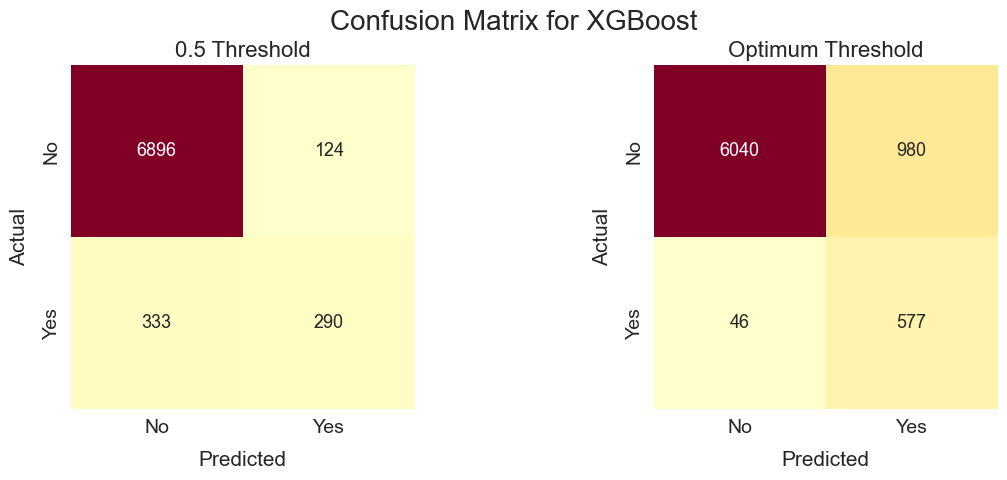

In [65]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
plt.suptitle('Confusion Matrix for XGBoost',y=0.95,fontsize=20)

sns.heatmap(confusion_matrix(ytest,xgb_yhat),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
            xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[0])
ax[0].set_title('0.5 Threshold',size=16)
ax[0].set_xlabel('Predicted',labelpad=10,size=15)
ax[0].set_ylabel('Actual',labelpad=10,size=15)
ax[0].tick_params(axis='both',labelsize=14);

sns.heatmap(confusion_matrix(ytest,xgb_opth),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
            xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[1])
ax[1].set_title('Optimum Threshold',size=16)
ax[1].set_xlabel('Predicted',labelpad=10,size=15)
ax[1].set_ylabel('Actual',labelpad=10,size=15)
ax[1].tick_params(axis='both',labelsize=14);

plt.tight_layout()

#### ANN

In [66]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import InputLayer,Flatten,Dense,BatchNormalization,Dropout
# from tensorflow.keras.regularizers import l1,l2,l1_l2
# from tensorflow.keras.callbacks import EarlyStopping
# from tensorflow.keras.utils import to_categorical
# from tensorflow.keras.metrics import BinaryAccuracy,Precision,Recall,F1Score,AUC
# from scikeras.wrappers import KerasClassifier
# tf.random.set_seed(42)

In [67]:
# def set_seed(seed):
#     os.environ['PYTHONHASHSEED'] = str(seed)
#     random.seed(seed)
#     tf.random.set_seed(seed)
#     np.random.seed(seed)
    
# def set_global_determinism(seed):
#     set_seed(seed)
#     os.environ['TF_DETERMINISTIC_OPS'] = '1'
#     os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
#     tf.config.threading.set_inter_op_parallelism_threads(1)
#     tf.config.threading.set_intra_op_parallelism_threads(1)
    
# set_global_determinism(42)

In [68]:
# def create_model():
#     model = Sequential()
#     model.add(Dense(16, input_dim=Xtrain.shape[1], activation='relu'))
#     model.add(Dense(8, activation='relu'))
#     model.add(Dense(1, activation='sigmoid'))
    
#     model.compile(optimizer='adam', loss='binary_crossentropy',metrics=[AUC(name='auc')])
#     return model

# pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', create_model())])

# history = pipeline.named_steps['model'].fit(
#     preprocessor.fit_transform(Xtrain), ytrain,
#     validation_data=(preprocessor.transform(Xtest), ytest),
#     epochs=20,
#     batch_size=10,
#     verbose=1
# )

In [69]:
# ytrain.astype('int')

In [70]:
# Xtrain

In [71]:
# # Xtrain = np.asarray(Xtrain)
# ytrain = np.asarray(ytrain).astype(np.int32)
# # Xtest = np.asarray(Xtest)
# ytest = np.asarray(ytest).astype(np.int32)

In [72]:
# ytrain_tensor = tf.convert_to_tensor(ytrain, dtype=tf.int64) 
# ytest_tensor = tf.convert_to_tensor(ytest, dtype=tf.int64) 

In [73]:
# # Function to create the ANN Model
# def create_model():
    
#     model = Sequential()
#     model.add(Dense(16, input_dim=len(Xtrain.columns), activation='relu'))
#     model.add(Dense(8, activation='relu'))
#     model.add(Dense(1, activation='sigmoid'))
    
#     model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
#     return model

# # Wrapping the Keras model with KerasClassifier for use in scikit-learn pipeline
# model = KerasClassifier(build_fn=create_model,epochs=20,batch_size=10,verbose=1)

# # Pipeline that includes preprocessing and model
# pipeline = Pipeline(steps=[('preprocessor',preprocessor),('model',model)])

# # Fitting the Model
# history = pipeline.fit(Xtrain,ytrain_tensor,model__validation_data=(Xtest,ytest_tensor))

# # Plotting Training and Validation Loss
# plt.plot(history.named_steps['model'].model.history.history['loss'], label='Training Loss')
# plt.plot(history.named_steps['model'].model.history.history['val_loss'], label='Validation Loss')
# plt.title('Model Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()

In [74]:
# type(ytrain.values)

In [75]:
# ann_model = Sequential([
#                        Dense(256,activation='relu',kernel_initializer='he_normal'),
#                     #    BatchNormalization(),
#                     #    Dropout(rate=0.1),
#                        Dense(128,activation='relu',kernel_initializer='he_normal'),
#                     #    BatchNormalization(),
#                     #    Dropout(rate=0.1),
#                        Dense(64,activation='relu',kernel_initializer='he_normal'),
#                     #    BatchNormalization(),
#                     #    Dropout(rate=0.1),
#                        Dense(1,activation='sigmoid')
#                        ])

# ann_model.compile(loss='binary_crossentropy',optimizer='adam',metrics=[AUC(name='auc')])

In [76]:
# # def create_model():
    
# #     model = Sequential([
# #                        Dense(256,activation='relu',kernel_initializer='he_normal'),
# #                     #    BatchNormalization(),
# #                     #    Dropout(rate=0.1),
# #                        Dense(128,activation='relu',kernel_initializer='he_normal'),
# #                     #    BatchNormalization(),
# #                     #    Dropout(rate=0.1),
# #                        Dense(64,activation='relu',kernel_initializer='he_normal'),
# #                     #    BatchNormalization(),
# #                     #    Dropout(rate=0.1),
# #                        Dense(1,activation='softmax')
# #                        ])

# #     model.compile(loss='binary_crossentropy',optimizer='adam',metrics=[AUC(name='auc')])
    
# #     return model
    
# # ann_model = KerasClassifier(build_fn=create_model,epochs=20,batch_size=32,verbose=0,validation_split=0.2,
# #                             callbacks=[EarlyStopping(patience=10,restore_best_weights=True)],random_state=42)

# ann_pipe = Pipeline([('preprocessor',preprocessor),('ann',ann_model)])

# history = ann_pipe.fit(Xtrain,ytrain)

# print('Train Set Results')
# # ann_yhat_train = ann_pipe.predict(Xtrain).round().astype('int').ravel()
# ann_yhat_train = ann_pipe.predict(Xtrain)
# print(f'ROC AUC Score: {roc_auc_score(ytrain,ann_yhat_train):0.2f}')

# # ann_yhat = ann_pipe.predict(Xtest).round().astype('int').ravel()
# ann_yhat = ann_pipe.predict(Xtest)
# # ann_yhat_prob = ann_pipe.predict_proba(Xtest)

# print('Test Set Results')
# print(f'ROC AUC Score: {roc_auc_score(ytest,ann_yhat):0.2f}')

In [77]:
# pd.DataFrame(history.named_steps['ann'].history).loc[:,('loss','val_loss')].plot(title='ANN Model Loss Progression across Epochs',
#                                                                                  xlabel='Epochs',ylabel='Loss');

In [78]:
# pd.DataFrame(history.history).loc[:,('auc','val_auc')].plot(title='ANN Model AUC Progression across Epochs',
#                                                             xlabel='Epochs',ylabel='Loss');

In [79]:
# ann_model.evaluate(Xtest_processed,ytest)

In [80]:
# ann_yhat = np.round(ann_model.predict(Xtest_processed)).ravel()
# ann_yhat_prob = ann_model.predict(Xtest_processed).ravel()

In [81]:
# def build_model(n_hidden=1,n_neurons=32,input_shape=Xtrain_res.shape[1:]):
    
#     model = Sequential()
#     model.add(InputLayer(input_shape=input_shape))
    
#     for i in range(n_hidden):
#         model.add(Dense(n_neurons,activation='relu',kernel_initializer='he_normal'))
        
#     model.add(Dense(1,activation='sigmoid'))
    
#     model.compile(loss='binary_crossentropy',optimizer='adam',metrics=[AUC()])
    
#     return model

# ann_model = KerasClassifier(build_model)

# ann_params = {'n_hidden':[2,3,4],
#               'n_neurons':[16,32,64]}

# ann_rand = RandomizedSearchCV(ann_model,ann_params,scoring='matthews_corrcoef',n_jobs=-1,cv=5,random_state=42)
# ann_rand.fit(Xtrain_res,ytrain_res,batch_size=32,epochs=20,validation_split=0.2,
#              callbacks=[EarlyStopping(patience=10,restore_best_weights=True)])

# print('Randomized Search CV Results')
# print(f'Best Score: {ann_rand.best_score_:0.2f}')
# print(f'Best Parameter Space: {ann_rand.best_params_}')

In [82]:
# ann_yhat = np.round(ann_rand.predict(Xtest_processed)).ravel()
# ann_yhat_prob = ann_rand.predict(Xtest_processed).ravel()

In [83]:
# classification_evaluation_charts(ytest,ann_yhat_prob)

In [84]:
# fpr,tpr,threshold_roc = roc_curve(ytest,ann_yhat_prob)
# optimal_idx = np.argmax(tpr-fpr)
# optimal_threshold_roc = threshold_roc[optimal_idx]

# ann_opth = (ann_yhat_prob > optimal_threshold_roc).astype(int)

In [85]:
# ann_metrics_50 = [precision_score(ytest,ann_yhat).round(2),
#                  recall_score(ytest,ann_yhat).round(2),
#                  f1_score(ytest,ann_yhat).round(2),
#                  roc_auc_score(ytest,ann_yhat).round(2),
#                  log_loss(ytest,ann_yhat).round(2),
#                  matthews_corrcoef(ytest,ann_yhat).round(2)]

# # ann_metrics_opth = [precision_score(ytest,ann_opth).round(2),
# #                    recall_score(ytest,ann_opth).round(2),
# #                    f1_score(ytest,ann_opth).round(2),
# #                    roc_auc_score(ytest,ann_opth).round(2),
# #                    log_loss(ytest,ann_opth).round(2),
# #                    matthews_corrcoef(ytest,ann_opth).round(2)]

In [86]:
# ann_metrics = pd.DataFrame(index=['Precision','Recall','F1','AUC','Log-Loss','Matthews-CorrCoef'],columns=['0.5 Threshold','Optimum Threshold'])
# ann_metrics['0.5 Threshold'] = ann_metrics_50
# # ann_metrics['Optimum Threshold'] = ann_metrics_opth
# ann_metrics

In [87]:
# print('Classification Report for ANN \n')

# print('\t\t\t 0.5 Threshold \n')
# print(classification_report(ytest,ann_yhat))

# # print('\t\t\t Optimum Threshold \n')
# # print(classification_report(ytest,ann_opth))

In [88]:
# fig,ax = plt.subplots(1,2,figsize=(12,5))
# plt.suptitle('Confusion Matrix for ANN',y=0.95,fontsize=20)

# sns.heatmap(confusion_matrix(ytest,ann_yhat),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
#             xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[0])
# ax[0].set_title('0.5 Threshold',size=16)
# ax[0].set_xlabel('Predicted',labelpad=10,size=15)
# ax[0].set_ylabel('Actual',labelpad=10,size=15)
# ax[0].tick_params(axis='both',labelsize=14);

# # sns.heatmap(confusion_matrix(ytest,ann_opth),square=True,annot=True,fmt='d',cmap='YlOrRd',cbar=False,
# #             xticklabels=['No','Yes'],yticklabels=['No','Yes'],annot_kws={'size':13},ax=ax[1])
# # ax[1].set_title('Optimum Threshold',size=16)
# # ax[1].set_xlabel('Predicted',labelpad=10,size=15)
# # ax[1].set_ylabel('Actual',labelpad=10,size=15)
# # ax[1].tick_params(axis='both',labelsize=14);

# plt.tight_layout()

## Saving the Trained Models 

In [103]:
import joblib

In [105]:
joblib.dump(search_lr_hyper,r'F:\Data Science Projects\Bank_Telemarketing\Bank_Telemarketing\models\lr_classifier.pkl')

['F:\\Data Science Projects\\Bank_Telemarketing\\Bank_Telemarketing\\models\\lr_classifier.pkl']

In [106]:
joblib.dump(search_knn_hyper,r'F:\Data Science Projects\Bank_Telemarketing\Bank_Telemarketing\models\knn_classifier.pkl')

['F:\\Data Science Projects\\Bank_Telemarketing\\Bank_Telemarketing\\models\\knn_classifier.pkl']

In [107]:
joblib.dump(search_svm_hyper,r'F:\Data Science Projects\Bank_Telemarketing\Bank_Telemarketing\models\svm_classifier.pkl')

['F:\\Data Science Projects\\Bank_Telemarketing\\Bank_Telemarketing\\models\\svm_classifier.pkl']

In [108]:
joblib.dump(search_rf_hyper,r'F:\Data Science Projects\Bank_Telemarketing\Bank_Telemarketing\models\rf_classifier.pkl')

['F:\\Data Science Projects\\Bank_Telemarketing\\Bank_Telemarketing\\models\\rf_classifier.pkl']

In [109]:
joblib.dump(search_xgb_hyper,r'F:\Data Science Projects\Bank_Telemarketing\Bank_Telemarketing\models\xgb_classifier.pkl')

['F:\\Data Science Projects\\Bank_Telemarketing\\Bank_Telemarketing\\models\\xgb_classifier.pkl']